In [3]:
import sqlite3
import os
import polars as pl
# import plot
import matplotlib.pyplot as plt
import numpy as np

In [51]:
# Configure LaTeX-like / math font for all plots in this notebook
# Prefer Cambria Math if available, fall back to STIX/Computer Modern.
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Cambria Math', 'STIXGeneral', 'Times New Roman', 'DejaVu Serif', 'Computer Modern'],
    # Use STIX math fonts for better LaTeX-like math rendering in Matplotlib's mathtext
    'mathtext.fontset': 'stix',
    'mathtext.rm': 'serif',
    'axes.unicode_minus': False
})
# You can re-run this cell to change font preferences globally for subsequent plots.

## Connect + Read from Database

### Set connection parameters

In [127]:
db_dir = "/scratch/aneeshr/concurrent-quit/results/db"
db_name = "db_oct30"
db_path = db_dir + "/" + db_name

In [128]:
connection = sqlite3.connect(db_path)

### Set the date/timestamp to read

In [129]:
date_to_read = "2025-07-02"

In [130]:
read_index_bench_query = f"SELECT * from index_bench where timestamp > {date_to_read};"

### Read the data

In [131]:
df = pl.read_database(
    query = read_index_bench_query, 
    connection = connection)

### Sample Read Data

In [132]:
filter_col = "index_type"
filter_predicate = "concurrent_quit_appends"

In [133]:
sample_filtered_result = df.filter(pl.col(filter_col) == filter_predicate)

In [134]:
sample_filtered_result

id,timestamp,index_type,workload_file,N,K,L,threads,preload_time,raw_writes_time,raw_reads_time,mixed_time,updates_time,short_range_time,mid_range_time,long_range_time,size,height,internal,leaves,fast_inserts,redistribute,soft_resets,hard_resets,fast_inserts_fail,sort
i64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
7,"""2025-10-30 16:02:38.908358+00:…","""concurrent_quit_appends""","""500_0_0""",500,0,0,1,60385554833,0,13858751996,0,57392213709,0,0,0,500000000,3,3921,999999,499000001,0,0,0,999999,0
8,"""2025-10-30 16:09:06.299375+00:…","""concurrent_quit_appends""","""500_5_100""",500,5,100,1,139941091511,0,15923573027,0,57794899657,0,0,0,500000000,3,5177,1398264,458167399,0,0,769522,41832601,1580653
9,"""2025-10-30 16:21:11.093719+00:…","""concurrent_quit_appends""","""500_50_100""",500,50,100,1,347199368951,0,29030310986,0,55925733666,0,0,0,500000000,3,5161,1663797,267462697,0,0,1889153,232537303,1591177
19,"""2025-10-30 18:11:54.816896+00:…","""concurrent_quit_appends""","""500_0_0""",500,0,0,2,191162170898,0,12238634179,0,37260904734,0,0,0,500000000,3,3920,999770,498939981,0,0,0,1060019,998792
20,"""2025-10-30 18:20:47.199926+00:…","""concurrent_quit_appends""","""500_5_100""",500,5,100,2,308628190241,0,13325208992,0,37503986245,0,0,0,500000000,3,5170,1399650,457690654,0,0,770610,42309346,1671785
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
58,"""2025-10-31 04:09:56.085180+00:…","""concurrent_quit_appends""","""500_5_100""",500,5,100,16,413998180291,0,6484296747,0,6038616016,0,0,0,500000000,3,5306,1443026,427176395,0,0,751900,72823605,1644597
59,"""2025-10-31 04:24:00.231741+00:…","""concurrent_quit_appends""","""500_50_100""",500,50,100,16,814576522755,0,5729069737,0,6296907634,0,0,0,500000000,3,5146,1662120,256003545,0,0,1787722,243996455,1534395
69,"""2025-10-31 06:05:46.877070+00:…","""concurrent_quit_appends""","""500_0_0""",500,0,0,32,366583042450,0,7437973380,0,5410075831,0,0,0,500000000,3,6322,1612321,485557946,0,0,4,14442054,971826


## Analysis

### Preload times

In [135]:
reset_df = df.select(
            pl.col("N"),
            pl.col("index_type"),
            pl.col("K"),
            pl.col("threads"),
            pl.col("preload_time"),
            # pl.col("hard_resets")
)
# reset_df = reset_df.filter((pl.col("index_type")=="concurrent_quit_appends") & (pl.col("K")==5))
# reset_df = reset_df.filter(((pl.col("index_type")=="concurrent_quit_appends") | 
#                             (pl.col("index_type")=="concurrent_quit_atomic")) &
#                            (pl.col("K")==50))
print(reset_df)

shape: (90, 5)
┌─────┬───────────────────┬─────┬─────────┬──────────────┐
│ N   ┆ index_type        ┆ K   ┆ threads ┆ preload_time │
│ --- ┆ ---               ┆ --- ┆ ---     ┆ ---          │
│ i64 ┆ str               ┆ i64 ┆ i64     ┆ i64          │
╞═════╪═══════════════════╪═════╪═════════╪══════════════╡
│ 500 ┆ concurrent_simple ┆ 0   ┆ 1       ┆ 124149757298 │
│ 500 ┆ concurrent_simple ┆ 5   ┆ 1       ┆ 148475514899 │
│ 500 ┆ concurrent_simple ┆ 50  ┆ 1       ┆ 315912011718 │
│ 500 ┆ concurrent_quit   ┆ 0   ┆ 1       ┆ 82879691026  │
│ 500 ┆ concurrent_quit   ┆ 5   ┆ 1       ┆ 143806283718 │
│ …   ┆ …                 ┆ …   ┆ …       ┆ …            │
│ 500 ┆ concurrent_tail   ┆ 5   ┆ 16      ┆ 421126174293 │
│ 500 ┆ concurrent_tail   ┆ 50  ┆ 16      ┆ 286821606849 │
│ 500 ┆ concurrent_tail   ┆ 0   ┆ 32      ┆ 433213247068 │
│ 500 ┆ concurrent_tail   ┆ 5   ┆ 32      ┆ 717574998591 │
│ 500 ┆ concurrent_tail   ┆ 50  ┆ 32      ┆ 473984576239 │
└─────┴───────────────────┴─────┴────────

In [136]:
preload_df = df.select(
                pl.col("index_type"), 
                pl.col("K"),
                pl.col("threads"),
                pl.col("preload_time")
)

In [137]:
num_ops = 500e6
div_factor = num_ops * 1000
preload_df = preload_df.with_columns((div_factor/pl.col("preload_time")).alias("throughput"))
preload_df

index_type,K,threads,preload_time,throughput
str,i64,i64,i64,f64
"""concurrent_simple""",0,1,124149757298,4.027394
"""concurrent_simple""",5,1,148475514899,3.367559
"""concurrent_simple""",50,1,315912011718,1.582719
"""concurrent_quit""",0,1,82879691026,6.032841
"""concurrent_quit""",5,1,143806283718,3.4769
…,…,…,…,…
"""concurrent_tail""",5,16,421126174293,1.187293
"""concurrent_tail""",50,16,286821606849,1.743244
"""concurrent_tail""",0,32,433213247068,1.154166


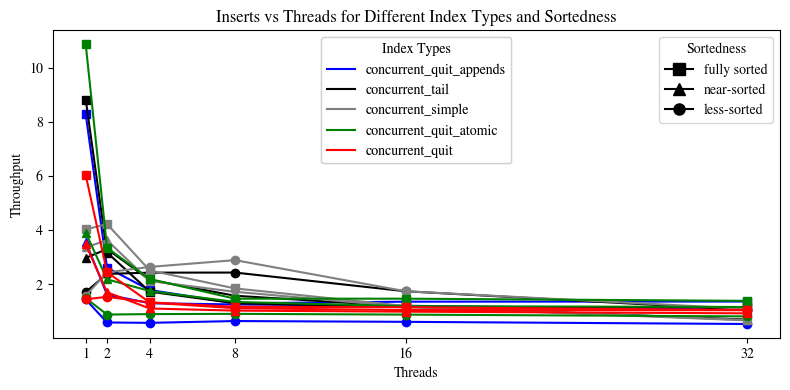

In [138]:
index_types = preload_df["index_type"].unique().to_list()
k_values = sorted(preload_df["K"].unique().to_list())
thread_values = sorted(preload_df["threads"].unique().to_list())

colors = {"concurrent_simple": "grey", "concurrent_tail": "black", "concurrent_quit": "red", 
          "concurrent_quit_appends": "blue", "concurrent_quit_atomic": "green"}
markers = {k: ['s', '^', 'o'][i % 3] for i, k in enumerate(k_values)}
sortedness_values = {0: "fully sorted", 5: "near-sorted", 50: "less-sorted"}

plt.figure(figsize=(8, 4))
lines = []
labels = []
for index in index_types:
    # Filter DataFrame by the current index type
    index_df = preload_df.filter(pl.col("index_type") == index).sort(["K", "threads"])
    # Iterate through each K value
    for k in k_values:
        # Filter DataFrame by the current K value
        k_df = index_df.filter(pl.col("K") == k).sort("threads")
        # Plot preload time against threads for this specific index type and K
        line, =plt.plot(k_df["threads"], k_df["throughput"],
                 label=f'K={k}',
                 color=colors[index],
                 marker=markers[k],
                 linestyle='-')
        lines.append(line)
        labels.append(f'{sortedness_values[k]}')

# Set x-axis ticks and label
plt.xticks(thread_values)
plt.xlabel("Threads")
# Set y-axis label
plt.ylabel("Throughput")
# Set plot title
plt.title("Inserts vs Threads for Different Index Types and Sortedness")
# Add legend

# legend_k_handles = [plt.plot([], [], marker=markers[k], linestyle='-', color='gray', label=f'K={k}')[0] for k in k_values]
# plt.legend(handles=legend_k_handles, title='K Values', loc='upper right')

# # Create a separate legend for Index Types using proxy artists
# legend_index_handles = [plt.plot([], [], color=colors[index], label=f'{index}')[0] for index in index_types]
# plt.legend(handles=legend_index_handles, loc='upper right')

# Create a separate legend for K values (proxy artists)
marker_handles = [plt.Line2D([0], [0], marker=markers[k], color='k', linestyle='-', markersize=8, label=f'{sortedness_values[k]}') for k in k_values]
legend2 = plt.legend(handles=marker_handles, title='Sortedness', loc='upper right')
plt.gca().add_artist(legend2) # Add the second legend to the current axes

# Create a separate legend for Index Types (proxy artists)
color_handles = [plt.Line2D([0], [0], color=colors[index], linestyle='-', label=f'{index}') for index in index_types]
legend3 = plt.legend(handles=color_handles, title='Index Types', loc='upper center')
plt.gca().add_artist(legend3) # Add the third legend to the current axes

# Adjust layout to prevent labels from overlapping
plt.tight_layout()
# Show the plot
plt.show()
# plt.savefig("updates-r-50m-july3.pdf")

In [143]:
legend_labels = {
    'concurrent_simple': 'B-tree',
    'concurrent_quit': 'QuIT Basic',
    'concurrent_quit_appends': 'QuIT with Lazy Appends',
    'concurrent_quit_atomic': 'Concurrent QuIT',
    'concurrent_tail': 'Tail B-tree'
}

In [140]:
# Function to plot throughput vs threads split by sortedness (one subplot per K)
def plot_by_sortedness(preload_df, index_pair, k_values=None, thread_values=None, colors=None, markers=None, sortedness_values=None, font_size=12):
    """Plot two or three index types across sortedness levels (K values).

    Args:
        preload_df: polars DataFrame with ['index_type','K','threads','throughput']
        index_pair: list/tuple of 2 or 3 index_type strings to plot
        k_values: list of K values (if None, inferred from preload_df)
        thread_values: list of thread counts for xticks (if None, inferred)
        colors: dict index_type->color (optional)
        markers: dict index_type->marker (optional) -- ignored; fixed markers used internally
        sortedness_values: dict K->label (optional)
        font_size: base font size (int) used for titles, labels, legend, ticks; default 12
    """
    # Normalize index_pair to list
    if not isinstance(index_pair, (list, tuple)):
        index_pair = [index_pair]
    index_pair = list(index_pair)

    if len(index_pair) not in (2, 3):
        raise ValueError("index_pair must contain exactly 2 or 3 index types")

    if k_values is None:
        k_values = sorted(preload_df["K"].unique().to_list())
    if thread_values is None:
        thread_values = sorted(preload_df["threads"].unique().to_list())
    if colors is None:
        colors = {"concurrent_simple": "grey", "concurrent_tail": "black","concurrent_quit": "red", "concurrent_quit_appends": "blue", "concurrent_quit_atomic": "green"}

    # Use a fixed, internal mapping of markers per index type so plots are
    # consistent and readable in black-and-white. This ignores any passed
    # `markers` parameter.
    markers_fixed = {
        "concurrent_simple": 's',
        "concurrent_quit": '^',
        "concurrent_quit_appends": 'o',
        "concurrent_quit_atomic": 'D',
        "concurrent_tail": 'v',
        # add more known index types here as desired
    }
    # fallback marker for unknown index types
    default_marker = 'o'
    # assign the markers variable used later to the fixed mapping
    markers = markers_fixed

    if sortedness_values is None:
        sortedness_values = {0: "fully sorted", 5: "near-sorted", 50: "less-sorted"}

    # Determine a common y-axis max across ALL index types present in preload_df
    # (y-axis limits should not depend on the requested index_pair)
    if preload_df is None or preload_df.height == 0:
        # no data available: choose a safe default
        global_ymax = 1.0
    else:
        try:
            # compute max throughput across the entire dataframe
            global_ymax = float(preload_df["throughput"].max())
            # guard against non-positive or NaN results
            if not (global_ymax and global_ymax > 0):
                global_ymax = 1.0
        except Exception:
            global_ymax = 1.0
    # add a small headroom to the maximum for visual spacing
    global_ymax = global_ymax * 1.05

    # scale figure size with font_size so larger fonts get more room
    scale = float(font_size) / 12.0
    n = len(k_values)
    fig_w = max(4, 5 * n * scale)
    fig_h = max(3, 4 * scale)
    fig, axes = plt.subplots(1, n, figsize=(fig_w, fig_h), sharey=True)
    if n == 1:
        axes = [axes]

    # tick and label font sizing
    tick_labelsize = int(max(8, font_size * 1))
    labelsize = int(max(9, font_size))
    title_size = int(max(10, font_size + 2))
    legend_size = int(max(8, int(font_size * 1)))

    # Plot data
    for ax, k in zip(axes, k_values):
        for idx in index_pair:
            k_df = preload_df.filter((pl.col("index_type") == idx) & (pl.col("K") == k)).sort("threads")
            if k_df.height == 0:
                # no data for this pairing: skip gracefully
                continue
            ax.plot(
                k_df["threads"],
                k_df["throughput"],
                label=legend_labels.get(idx, idx) if 'legend_labels' in globals() else idx,
                color=colors.get(idx, 'k'),
                marker=markers.get(idx, default_marker),
                fillstyle='none',
                linestyle='-'
            )
        # per-axis formatting
        # ax.set_title(sortedness_values.get(k, f'K={k}'), fontsize=title_size)
        ax.set_xticks(thread_values)
        ax.set_xlabel("Threads", fontsize=labelsize)
        ax.tick_params(axis='both', which='major', labelsize=tick_labelsize)
        ax.grid(True, linestyle=':', alpha=0.4)
        # set unified y limits
        ax.set_ylim(0, global_ymax)
        # add per-axis legend only for 2-index plots to avoid duplicates
        if len(index_pair) == 2:
            ax.legend(fontsize=legend_size, frameon=False, ncol=1, loc='best')

    # If there are >2 index types, create a single centered legend for the whole figure
    if len(index_pair) > 2:
        # collect unique handles/labels from all axes in plotting order
        handles = []
        labels = []
        for ax in axes:
            h, l = ax.get_legend_handles_labels()
            for hi, li in zip(h, l):
                if li not in labels:
                    handles.append(hi)
                    labels.append(li)
        # remove per-axis legends if any
        for ax in axes:
            leg = ax.get_legend()
            if leg:
                leg.remove()
        # place figure-level legend centered above subplots
        # ncol equal to number of index types keeps legend compact
        fig.legend(handles, labels, loc='upper center', ncol=len(index_pair), fontsize=legend_size, frameon=False, bbox_to_anchor=(0.5, 1.05))
        # adjust subplots to make space for the legend
        fig.subplots_adjust(top=0.86)

    axes[0].set_ylabel("Throughput (Mops/sec)", fontsize=labelsize)
    plt.tight_layout()
    plt.show()


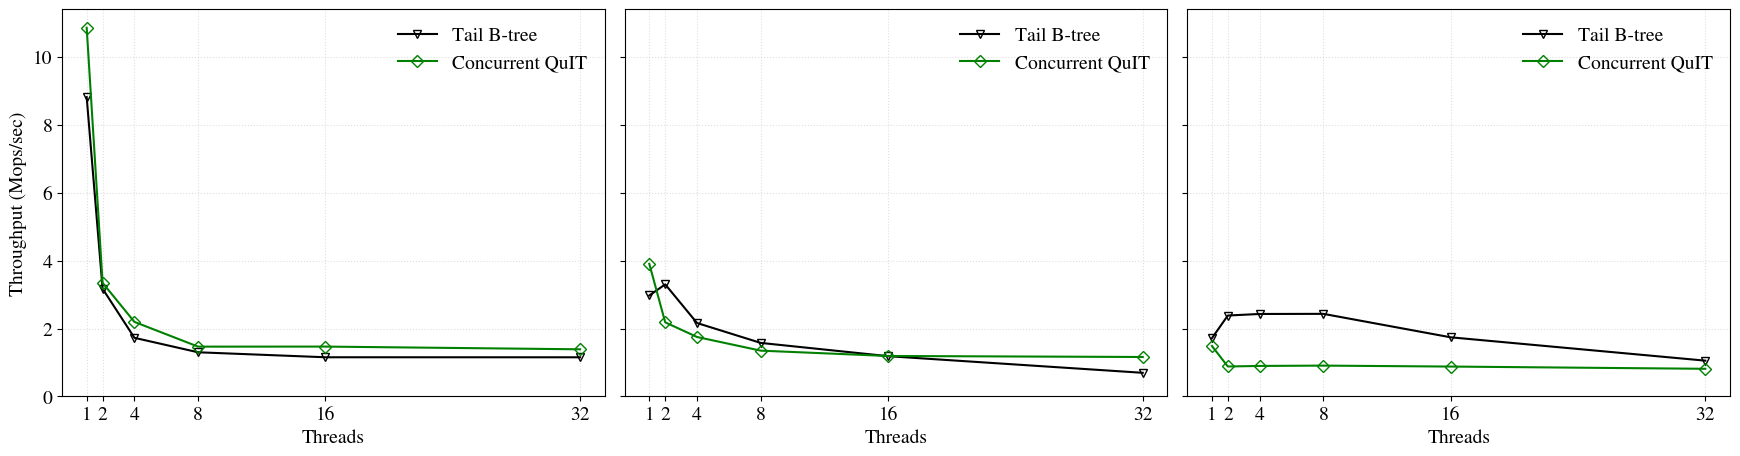

In [144]:
# Call the plotting function for concurrent_simple and concurrent_quit
plot_by_sortedness(preload_df, ["concurrent_tail", "concurrent_quit_atomic"], font_size=14)

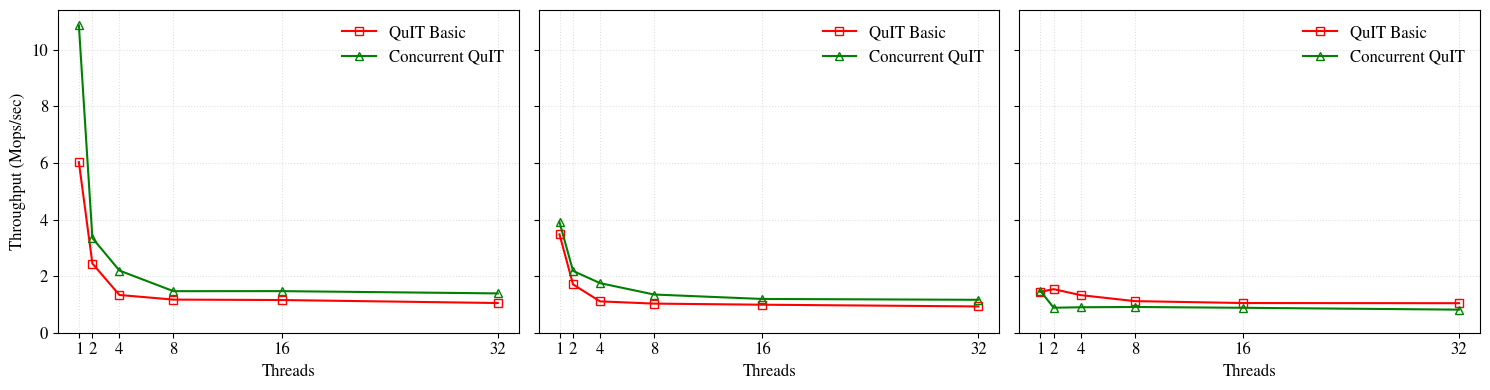

In [122]:
plot_by_sortedness(preload_df, ["concurrent_quit", "concurrent_quit_atomic"])

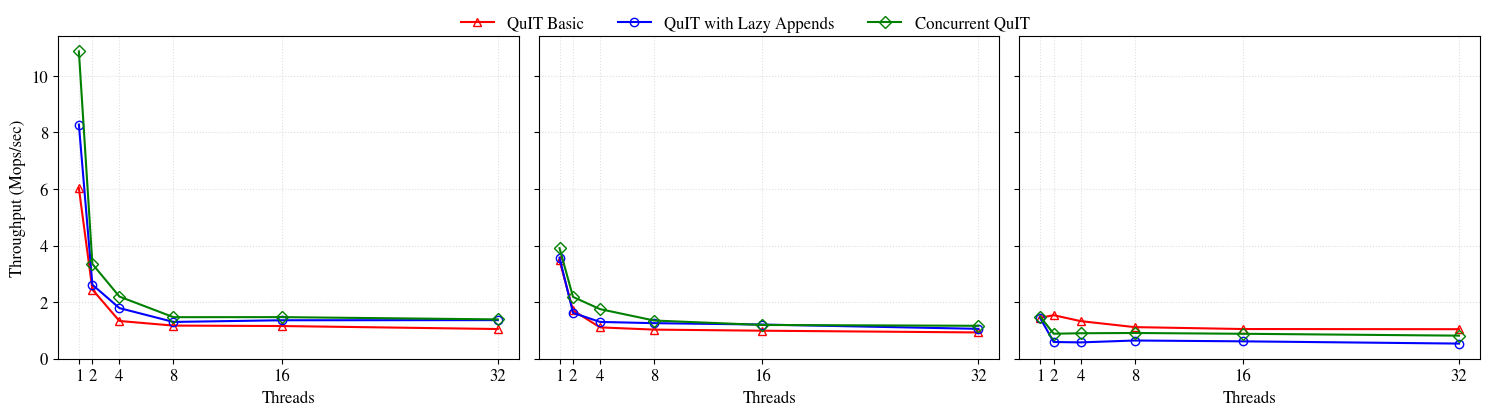

In [125]:
plot_by_sortedness(preload_df, ["concurrent_quit", "concurrent_quit_appends", "concurrent_quit_atomic"])